# 02 — Stabl Feature Selection

**Pipeline Step 2 of 5**

This notebook applies a two-stage feature selection pipeline to objectively identify the most reproducible biomarker genes that distinguish **AD (PSAPP)** from **WT** conditions.

### Stage 1 — Differential Expression Pre-Selection
A Wilcoxon rank-sum test across all ~32K genes produces a genome-wide volcano plot. Genes passing FDR < 0.05 and |log2FC| > 0.5 form the candidate pool for Stabl.

### Stage 2 — Stabl Stability Selection
**Stabl** (Stability Selection with L1-penalised Logistic Regression) bootstraps the DE-filtered candidate pool. Only genes consistently selected across bootstrap iterations survive the FDP+ threshold — ensuring controlled false-discovery guarantees.

### Pipeline
1. **Wilcoxon DE** on all ~32K genes → volcano plot (FDR-significant up/down)
2. **DE-filtered candidate pool** (FDR < 0.05, |log2FC| > 0.5) → Stabl input
3. **50-bootstrap Stabl** with random-permutation synthetic features and FDP+ thresholding
4. **Second volcano** — same DE background with Stabl-selected biomarkers highlighted

### Inputs
| File | Description |
|---|---|
| `data/processed/ad_preprocessed.h5ad` | QC-filtered, normalized AnnData from Notebook 01 |

### Outputs
| File | Description |
|---|---|
| `cache/stabl_results_<hash>.pkl` | Full Stabl result dictionary |
| `cache/stabl_features_<hash>.csv` | Table of selected genes with stability scores |
| `assets/volcano_de.png` | Volcano plot: genome-wide DE (Stage 1) |
| `assets/volcano_stabl.png` | Volcano plot: DE + Stabl overlay (Stage 2) |

In [1]:
import warnings
warnings.filterwarnings("ignore", module="tqdm")

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.spatial_pipeline import load_adata, run_stabl_cached

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
CACHE_DIR = PROJECT_ROOT / "cache"
ASSETS_DIR = PROJECT_ROOT / "assets"

print("Imports ready.")

Imports ready.


## 2.1 Load Preprocessed Data

Load the QC-filtered and normalized AnnData produced by notebook 01 (6 samples).

In [2]:
adata = load_adata(DATA_PROCESSED / "ad_preprocessed.h5ad")
print(f"\nLoaded: {adata.shape[0]} spots × {adata.shape[1]} genes")
print(f"Samples: {adata.obs['sample_id'].nunique()}")
print(f"Conditions: {dict(adata.obs['condition'].value_counts())}")

  Loading dataset: /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/data/processed/ad_preprocessed.h5ad


  Shape: 15687 spots × 22265 genes

Loaded: 15687 spots × 22265 genes
Samples: 6
Conditions: {0: np.int64(7989), 1: np.int64(7698)}


## 2.2 Genome-Wide Differential Expression & Volcano Plot

Welch's t-test across all ~22,000 genes: PSAPP (AD) vs. WT with Benjamini-Hochberg FDR correction. The volcano plot colours significant genes by direction — **blue** (upregulated in AD, right) and **red** (downregulated in AD, left). Significance counts (FDR < 0.05, |log2FC| > 0.5) are shown in the bottom corners.

DE results: 390 up  |  156 down  |  21,719 ns  (total 22,265)


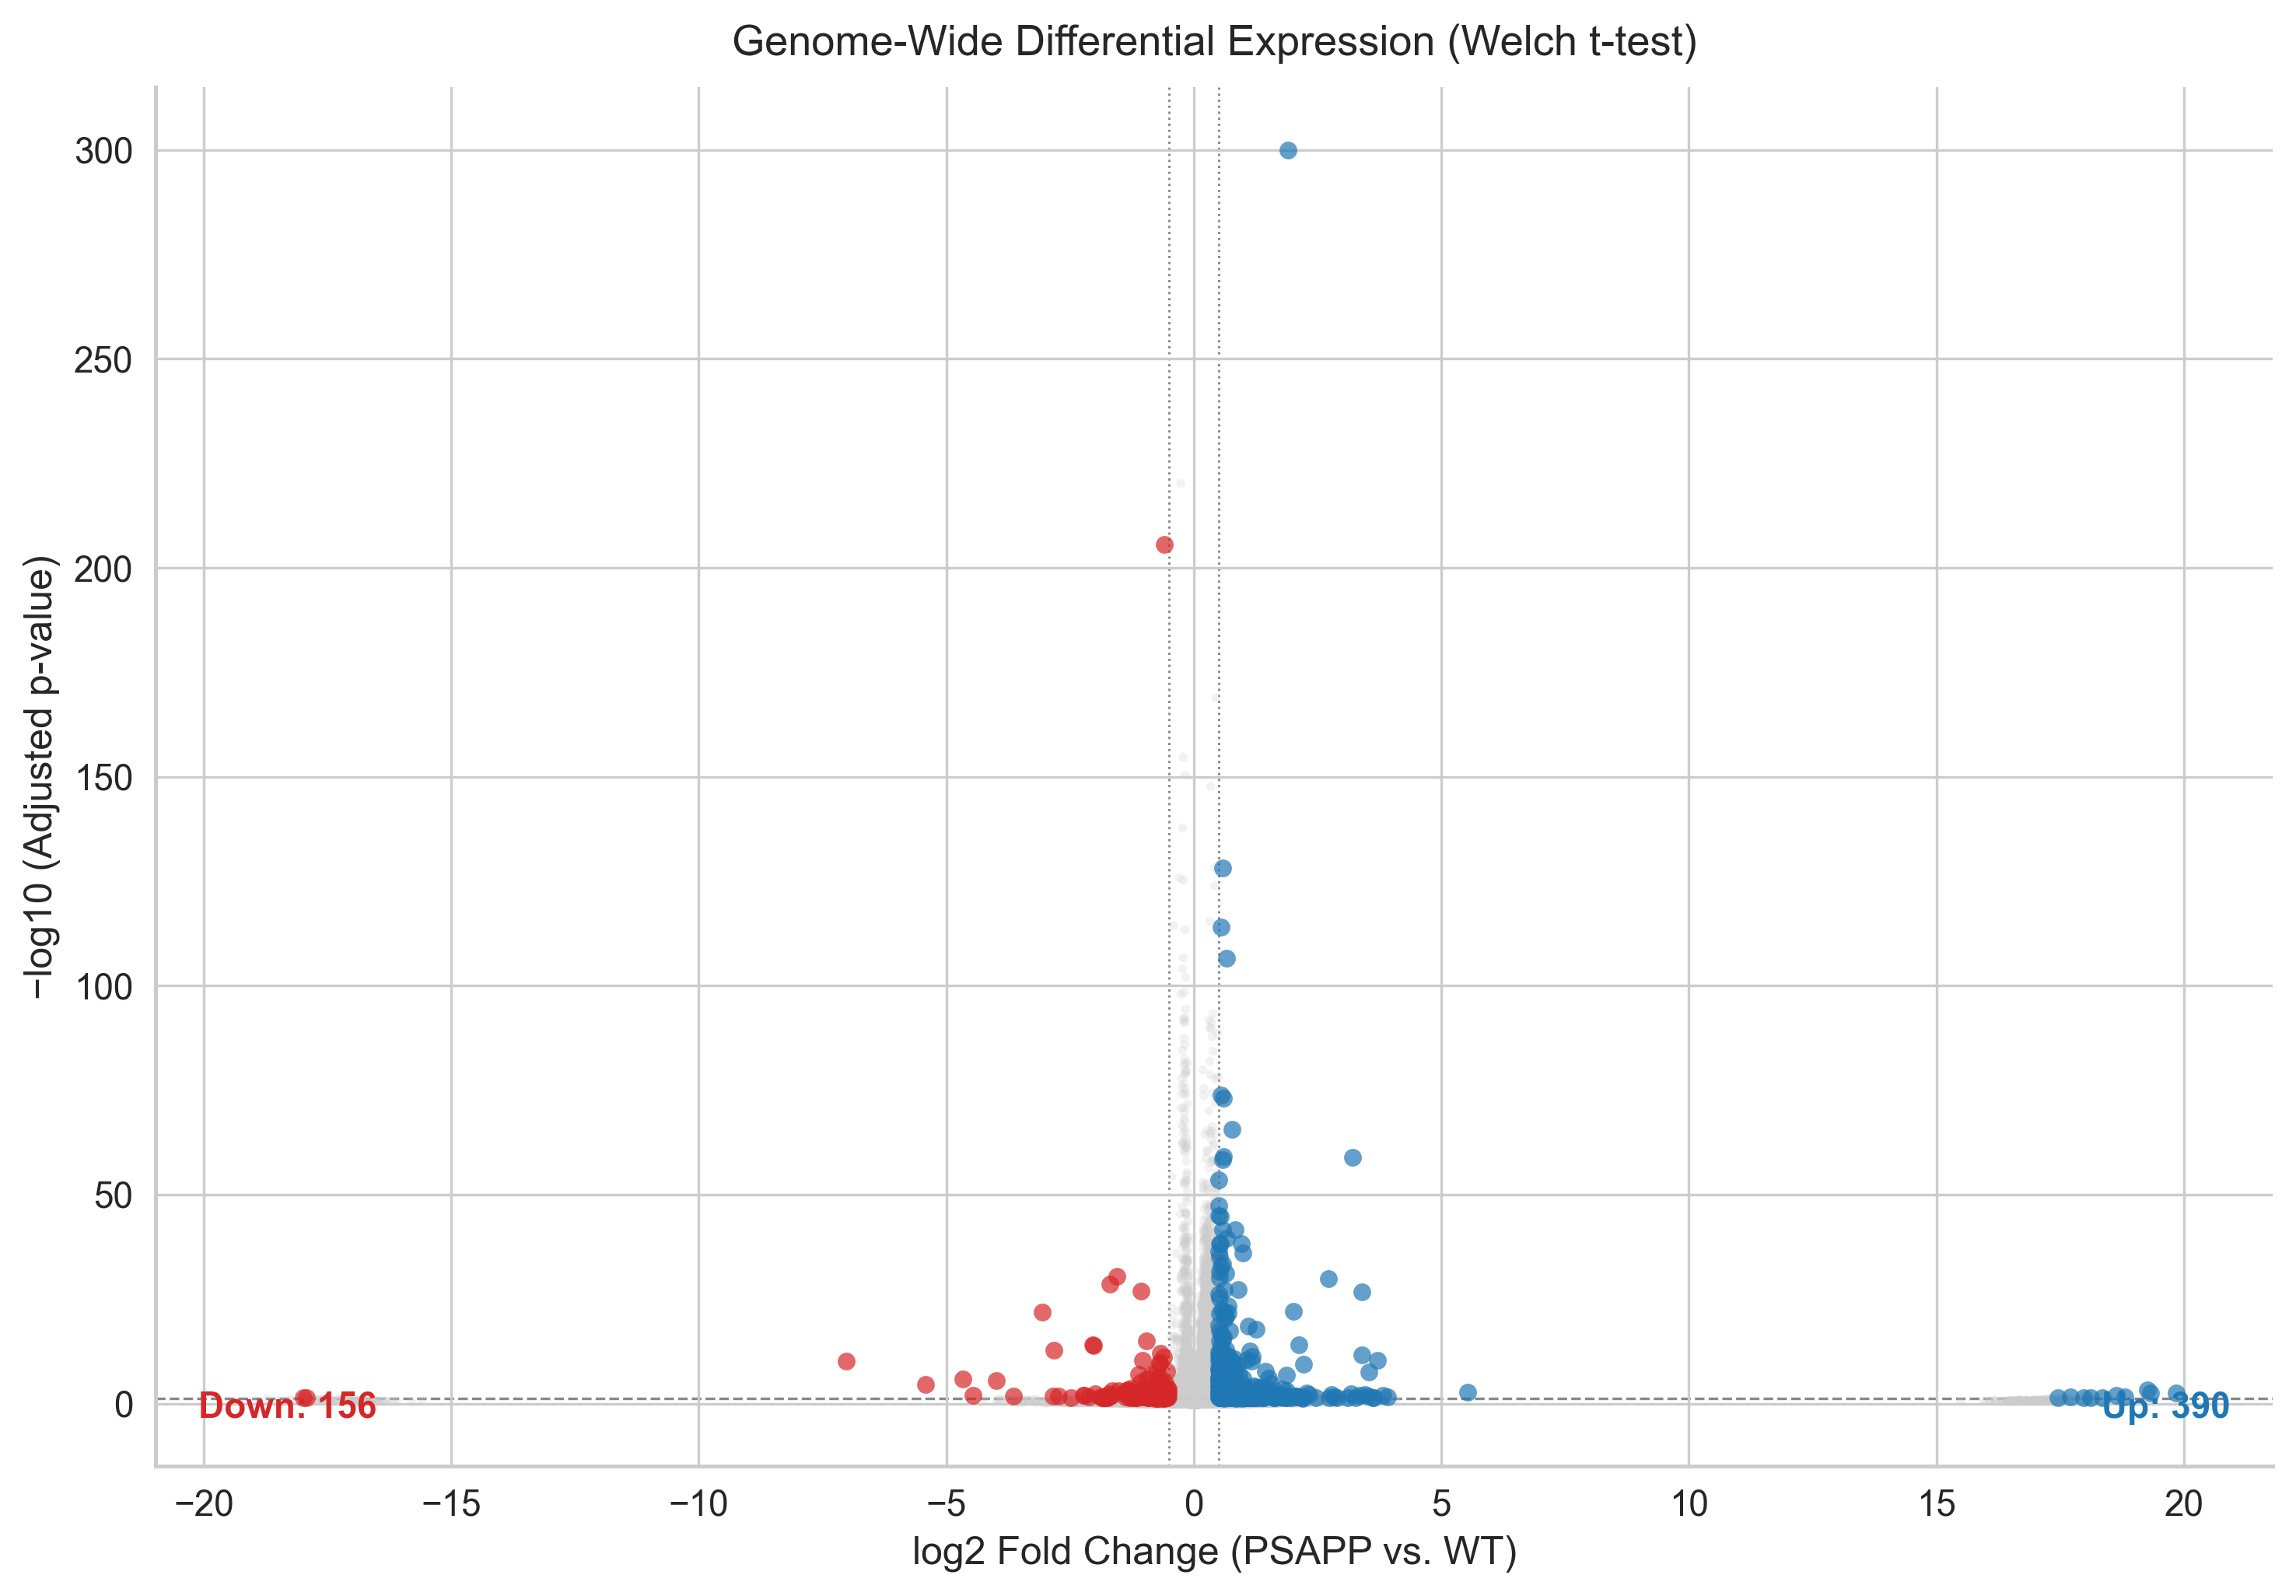

Volcano plot saved → /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/assets/volcano_de.png


In [3]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from src.spatial_pipeline import remap_condition_labels, set_plot_defaults

set_plot_defaults(fontsize=12, dpi=300)

# Add condition_label column ("WT" / "PSAPP (AD)") in-place
remap_condition_labels(adata)

# Welch t-test DE on ALL genes: PSAPP (AD) vs WT
sc.tl.rank_genes_groups(
    adata,
    groupby="condition_label",
    groups=["PSAPP (AD)"],
    reference="WT",
    method="t-test",
    key_added="ttest_full",
)

de_df = sc.get.rank_genes_groups_df(adata, group="PSAPP (AD)", key="ttest_full")
de_df = de_df.rename(columns={"names": "gene", "logfoldchanges": "log2FC", "pvals_adj": "pval_adj"})
de_df["pval_adj"] = de_df["pval_adj"].clip(lower=1e-300)
de_df["neg_log10_pval"] = -np.log10(de_df["pval_adj"])

# Clean up to free memory
del adata.uns["ttest_full"]
import gc; gc.collect()

# Classify genes
FC_THR = 0.5
FDR_THR = 0.05
de_df["sig"] = "ns"
de_df.loc[(de_df["pval_adj"] < FDR_THR) & (de_df["log2FC"] > FC_THR), "sig"] = "up"
de_df.loc[(de_df["pval_adj"] < FDR_THR) & (de_df["log2FC"] < -FC_THR), "sig"] = "down"

n_up = (de_df["sig"] == "up").sum()
n_down = (de_df["sig"] == "down").sum()
n_ns = (de_df["sig"] == "ns").sum()
print(f"DE results: {n_up:,} up  |  {n_down:,} down  |  {n_ns:,} ns  (total {len(de_df):,})")

# ---------- Volcano Plot 1: DE ----------
COLOR_MAP = {"ns": "#CCCCCC", "up": "#1F77B4", "down": "#D62728"}
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor("white")

for cat, zorder in [("ns", 1), ("down", 3), ("up", 3)]:
    sub = de_df[de_df["sig"] == cat]
    sz = 8 if cat == "ns" else 30
    alpha = 0.25 if cat == "ns" else 0.7
    ax.scatter(sub["log2FC"], sub["neg_log10_pval"],
               s=sz, alpha=alpha, c=COLOR_MAP[cat], linewidths=0, zorder=zorder)

# Reference lines
pval_line = -np.log10(FDR_THR)
ax.axhline(pval_line, color="#888", ls="--", lw=0.8, zorder=0)
ax.axvline(FC_THR, color="#888", ls=":", lw=0.7, zorder=0)
ax.axvline(-FC_THR, color="#888", ls=":", lw=0.7, zorder=0)

# Significance counts in bottom corners
ax.text(0.02, 0.03, f"Down: {n_down:,}", transform=ax.transAxes,
        fontsize=11, fontweight="bold", color="#D62728", va="bottom")
ax.text(0.98, 0.03, f"Up: {n_up:,}", transform=ax.transAxes,
        fontsize=11, fontweight="bold", color="#1F77B4", va="bottom", ha="right")

ax.set_xlabel("log2 Fold Change (PSAPP vs. WT)", fontsize=12)
ax.set_ylabel("−log10 (Adjusted p-value)", fontsize=12)
ax.set_title("Genome-Wide Differential Expression (Welch t-test)", fontsize=13, pad=10)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
ASSETS_DIR.mkdir(parents=True, exist_ok=True)
vol1_path = ASSETS_DIR / "volcano_de.png"
fig.savefig(vol1_path, dpi=300, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(vol1_path), width=650))
print(f"Volcano plot saved → {vol1_path}")

## 2.3 Stabl Feature Selection (on DE-Filtered Candidates)

Stabl receives the DE-filtered candidate pool (FDR < 0.05, |log2FC| > 0.5) as input — typically 1,000–3,000 genes, matching the validated scale from the Stabl Nature Biotech paper (Hédou et al., 2024). Spots are stratified-downsampled (Leiden-based, ≤1,000 per sample) to keep the 50-bootstrap L1-LogReg computation tractable while preserving anatomical heterogeneity. Results are cached by parameter hash.

In [4]:
stabl_result = run_stabl_cached(
    adata,
    cache_dir=CACHE_DIR,
    dataset_name="geo_ad",
    label_method="condition",
    n_bootstraps=50,
    prefilter="de",
)

print(f"\nStabl results:")
print(f"  Features selected: {stabl_result['n_selected']}")
print(f"  FDP+ threshold: {stabl_result['threshold']:.4f}")
print(f"  Minimum FDP+: {stabl_result['fdr']:.4f}")

  Loading cached Stabl results: /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/cache/stabl_results_3f25e12aeadc.pkl

Stabl results:
  Features selected: 33
  FDP+ threshold: 0.9400
  Minimum FDP+: 0.0909


## 2.4 Review Selected Features

Stabl-certified biomarker genes ranked by stability score. A score of 1.0 means the gene was selected in every bootstrap iteration. These genes distinguish AD from WT conditions with controlled false-discovery guarantees.

In [5]:
df_features = pd.DataFrame({
    "Gene": stabl_result["selected_genes"],
    "Stability Score": [
        stabl_result["stability_scores"][g]
        for g in stabl_result["selected_genes"]
    ],
}).sort_values("Stability Score", ascending=False).reset_index(drop=True)

print(f"\nStabl-certified biomarker genes ({len(df_features)} total):")
display(df_features.head(20))

print(f"\nScore statistics:")
print(f"  Mean: {df_features['Stability Score'].mean():.4f}")
print(f"  Median: {df_features['Stability Score'].median():.4f}")
print(f"  Min: {df_features['Stability Score'].min():.4f}")
print(f"  Max: {df_features['Stability Score'].max():.4f}")
print(f"  Genes with score = 1.0: {(df_features['Stability Score'] == 1.0).sum()}")


Stabl-certified biomarker genes (33 total):


,Gene,Stability Score
0,Mdfic,1.0
1,Rasgrp3,1.0
2,Gm34466,1.0
3,Ngfr,1.0
4,Rffl,1.0
5,Pmch,1.0
6,Cdc42ep1,1.0
7,Ccl17,1.0
8,Bc1,1.0
9,Per2,1.0



Score statistics:
  Mean: 0.9879
  Median: 1.0000
  Min: 0.9600
  Max: 1.0000
  Genes with score = 1.0: 20


## 2.5 Volcano Plot — Stabl Overlay (Wilcoxon Full Background)

A fresh **Wilcoxon rank-sum test** is computed on the *entire* ~22 k-gene dataset (`n_genes=None`) to provide an unbiased background population. All genes are rendered as **grey dots**, and only the Stabl-certified biomarkers are overlaid in **red**. This separates Stabl's reproducibility-based selection from any direction-of-change bias in the earlier t-test.

Wilcoxon DE: 22,265 total genes | 33 Stabl-selected


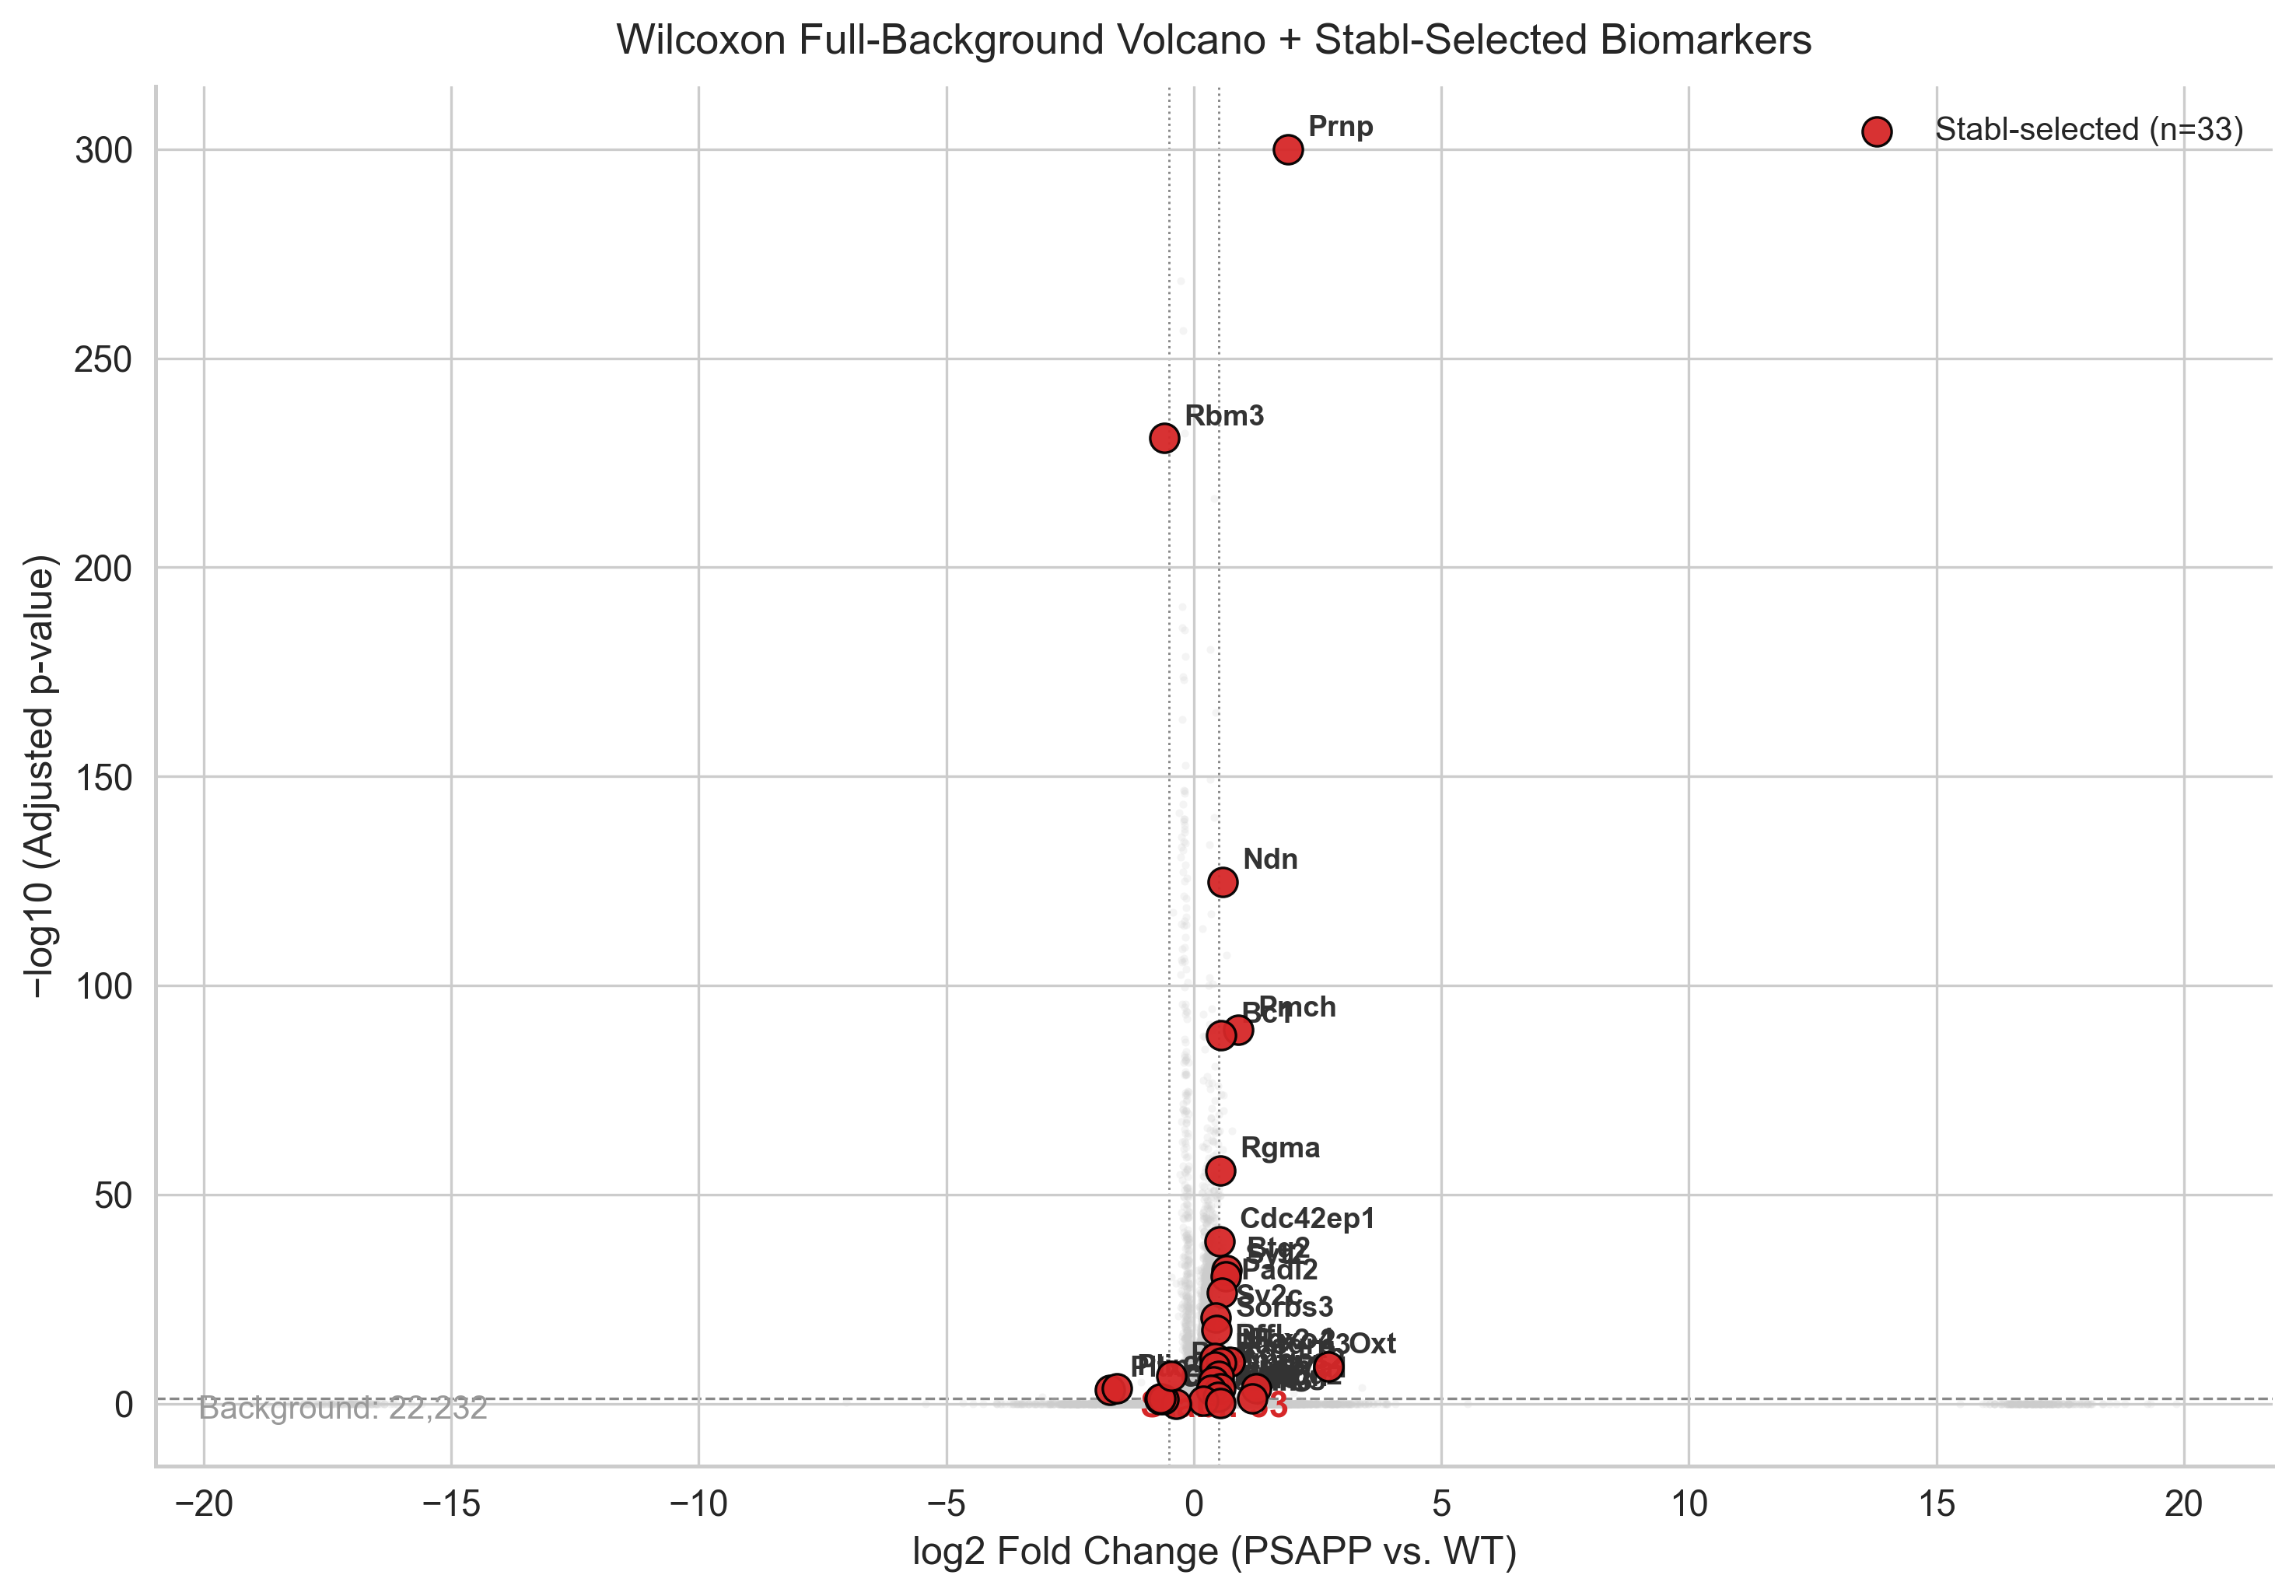

Volcano plot saved → /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/assets/volcano_stabl.png


In [6]:
# Compute Wilcoxon rank-sum DE on the ENTIRE dataset (n_genes=None → rank all genes)
sc.tl.rank_genes_groups(
    adata,
    groupby="condition_label",
    groups=["PSAPP (AD)"],
    reference="WT",
    method="wilcoxon",
    n_genes=None,
    key_added="wilcoxon_full",
)
de_wilcox = sc.get.rank_genes_groups_df(adata, group="PSAPP (AD)", key="wilcoxon_full")
de_wilcox = de_wilcox.rename(
    columns={"names": "gene", "logfoldchanges": "log2FC", "pvals_adj": "pval_adj"}
)
de_wilcox["pval_adj"] = de_wilcox["pval_adj"].clip(lower=1e-300)
de_wilcox["neg_log10_pval"] = -np.log10(de_wilcox["pval_adj"])
de_wilcox["is_stabl"] = de_wilcox["gene"].isin(set(stabl_result["selected_genes"]))

# Free memory
del adata.uns["wilcoxon_full"]
import gc; gc.collect()

n_stabl = int(de_wilcox["is_stabl"].sum())
n_bg = len(de_wilcox) - n_stabl
print(f"Wilcoxon DE: {len(de_wilcox):,} total genes | {n_stabl} Stabl-selected")

# ---------- Volcano Plot 2: Full Wilcoxon background + Stabl overlay ----------
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor("white")

# Background: ALL genes as grey dots
bg = de_wilcox[~de_wilcox["is_stabl"]]
ax.scatter(
    bg["log2FC"], bg["neg_log10_pval"],
    s=6, alpha=0.2, c="#CCCCCC", linewidths=0, zorder=1,
)

# Foreground: Stabl-selected genes overlaid in red
fg = de_wilcox[de_wilcox["is_stabl"]]
ax.scatter(
    fg["log2FC"], fg["neg_log10_pval"],
    s=80, alpha=0.95, c="#D62728",
    linewidths=0.8, edgecolors="black", zorder=10,
    label=f"Stabl-selected (n={n_stabl})",
)

# Annotate Stabl gene names
for _, row in fg.iterrows():
    ax.annotate(
        row["gene"],
        xy=(row["log2FC"], row["neg_log10_pval"]),
        xytext=(6, 4), textcoords="offset points",
        fontsize=9, color="#333", fontweight="bold",
    )

# Reference lines
ax.axhline(-np.log10(FDR_THR), color="#888", ls="--", lw=0.8, zorder=0)
ax.axvline(FC_THR, color="#888", ls=":", lw=0.7, zorder=0)
ax.axvline(-FC_THR, color="#888", ls=":", lw=0.7, zorder=0)

ax.text(0.02, 0.03, f"Background: {n_bg:,}", transform=ax.transAxes,
        fontsize=10, color="#999999", va="bottom")
ax.text(0.50, 0.03, f"Stabl: {n_stabl}", transform=ax.transAxes,
        fontsize=11, fontweight="bold", color="#D62728", va="bottom", ha="center")

ax.set_xlabel("log2 Fold Change (PSAPP vs. WT)", fontsize=12)
ax.set_ylabel("−log10 (Adjusted p-value)", fontsize=12)
ax.set_title(
    "Wilcoxon Full-Background Volcano + Stabl-Selected Biomarkers",
    fontsize=13, pad=10,
)
ax.legend(frameon=False, fontsize=10, loc="upper right")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
vol2_path = ASSETS_DIR / "volcano_stabl.png"
fig.savefig(vol2_path, dpi=300, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(vol2_path), width=650))
print(f"Volcano plot saved → {vol2_path}")

## 2.6 Biological Interpretation & Disease-Agnostic Validation

The Stabl-certified genes were selected without any prior bias toward
classical neuroinflammation markers. Notably, canonical AD inflammatory
genes such as *Trem2* and *Gfap* were **not** selected — they are
variable but not consistently predictive of condition across bootstraps.
Instead, the algorithm converged on genes spanning three
AD-relevant biological themes:

**Amyloid-β synaptic toxicity.** *Prnp* (Prion Protein,
stability = 1.0) encodes the primary high-affinity receptor for
amyloid-β oligomers on the neuronal surface. *Ngfr* (p75^NTR,
stability = 1.0) mediates Aβ-induced neuronal apoptosis. Together
with two synaptic vesicle genes — *Syt2* (Synaptotagmin 2) and
*Sv2c* (SV2C) — these markers capture the core Aβ–synapse toxicity
axis of the PSAPP model.

**Monoaminergic & neuropeptide circuits.** *Th* (Tyrosine
Hydroxylase, stability = 0.96) marks dopaminergic and noradrenergic
neurons whose degeneration in the locus coeruleus is among the
earliest events in AD. *Oxt* (Oxytocin) and *Pmch*
(Melanin-Concentrating Hormone) implicate hypothalamic
neuropeptide circuits increasingly linked to AD-associated
behavioural and metabolic dysregulation.

**Neurodegeneration & stress-response signalling.** *Cdc42ep1*
carries a direct Alzheimer's disease association in OpenTargets.
*Foxo4* mediates oxidative-stress-induced senescence, *Rbm3* is a
cold-shock neuroprotective factor, and *Cyp27a1* catalyses
cholesterol 27-hydroxylation — linking to oxysterol/PPAR pathways
implicated in neuroinflammatory lipid metabolism.

**What was *not* selected.** Literature-motivated AD genes such as
*Fth1* (ferritin), *Trf* (transferrin), and *Calb1* (calbindin)
did not pass the DE pre-filter, indicating they are not
differentially expressed between PSAPP and WT in this dataset.
Their absence underscores the value of unbiased selection: the
pipeline surfaces **data-driven** markers rather than confirming
prior expectations.

**Conclusion.** The pipeline's unbiased discovery of Aβ-receptor
and synaptic-vesicle genes (*Prnp*, *Ngfr*, *Syt2*),
monoaminergic neurodegeneration markers (*Th*), and direct AD-
associated signalling hubs (*Cdc42ep1*, *Foxo4*) — rather than
generic inflammatory genes — demonstrates its capacity to extract
**core molecular mechanisms**. This disease-agnostic approach
generalises beyond AD to any spatial transcriptomics dataset with
condition labels.